In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
chec_sumprom_glob = "sumproms/*.gz"

# Extracted kmer files (see analysis code for calculation)
kmer_7mer_files_glob = "../Experimental_data_analysis/kmer_avg_signal_files/*7mer*.csv"

# Extracted footprint directory (see analysis code for calculation)
footprint_dir = "../Experimental_data_analysis/fimo_footprints/fig1/"
erg_fp_on_erg_path = f"{footprint_dir}erg_atf1_on_ERG/raw_signals/ERG_raw_windows.csv"
atf1_fp_on_erg_path = f"{footprint_dir}erg_atf1_on_ERG/raw_signals/ATF1_raw_windows.csv"
erg_fp_on_atf1_path = f"{footprint_dir}erg_atf1_on_ATF1/raw_signals/ERG_raw_windows.csv"
atf1_fp_on_atf1_path = f"{footprint_dir}erg_atf1_on_ATF1/raw_signals/ATF1_raw_windows.csv"

# HOCOMOCO v12 pfm files, available for download online
erg_pfm = "../pfm/ERG.H12CORE.1.SM.B.pfm"
atf1_pfm = "../pfm/ATF1.H12CORE.0.P.B.pfm"

## Imports

In [3]:
import glob
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from typing import Optional, Sequence, Tuple

import seaborn as sns
import logomaker as lm

## Helper Functions

In [4]:
# Extract the shared sample name from each 7mer signal filename.
def get_prefix(fname):
    base = os.path.basename(fname).split(".")[0]
    parts = base.split("_")
    if len(parts) > 3:
        return "_".join(parts[:-3])
    return base

# Match IUPAC motif symbols against concrete bases.
IUPAC = {
    "A": {"A"}, "C": {"C"}, "G": {"G"}, "T": {"T"},
    "R": {"A", "G"}, "Y": {"C", "T"}, "S": {"G", "C"}, "W": {"A", "T"},
    "K": {"G", "T"}, "M": {"A", "C"}, "B": {"C", "G", "T"}, "D": {"A", "G", "T"},
    "H": {"A", "C", "T"}, "V": {"A", "C", "G"}, "N": {"A", "C", "G", "T"},
}
COMP = {
    "A": "T", "C": "G", "G": "C", "T": "A",
    "R": "Y", "Y": "R", "S": "S", "W": "W",
    "K": "M", "M": "K", "B": "V", "V": "B", "D": "H", "H": "D", "N": "N",
}

# Check whether two IUPAC symbols can represent at least one shared base.
def _m(a, b):
    return not IUPAC.get(a, {a}).isdisjoint(IUPAC.get(b, {b}))

# Compute the reverse complement of an IUPAC motif string.
def _rc(s):
    return "".join(COMP.get(c, c) for c in s.upper()[::-1])

# Measure the longest common subsequence between two IUPAC-aware strings.
def _lcs_len_iupac(s1, s2):
    dp = [0] * (len(s2) + 1)
    for x in s1:
        prev = 0
        for j, y in enumerate(s2, 1):
            prev, dp[j] = dp[j], (prev + 1 if _m(x, y) else max(dp[j], dp[j - 1]))
    return dp[-1]

# Score each 7mer against a motif and its reverse complement.
def iupac_similarity(kmer, motif):
    a = kmer.upper()
    b = motif.upper()
    brc = _rc(motif)
    return max(_lcs_len_iupac(a, b), _lcs_len_iupac(a, brc))

# Keep only the positional columns that exist in a requested window.
def _pos_cols_in(df: pd.DataFrame, rng: Sequence[int]) -> list[str]:
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]

# Sort rows by central signal and return the columns used for plotting.
def _sorted_and_window(df: pd.DataFrame, width: int) -> tuple[pd.DataFrame, list[str]]:
    if width < 1:
        raise ValueError("width must be >= 1")

    sort_range = range(-25, 26)
    heat_range = range(-width, width + 1)

    sort_cols = _pos_cols_in(df, sort_range)
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    heat_cols = _pos_cols_in(df_sorted, heat_range)
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols

## Replicate Correlation Heatmap

In [5]:
# Load promoter-level signal matrices
chec_sumprom_files = glob.glob(chec_sumprom_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in chec_sumprom_files], axis=1)

# Convert to z-score
sumprom_all_z = sumprom_all.apply(zscore)

# Group the replicates that should appear together in the heatmap.
samples_to_plot = {
    "ERG": ["ERG_1_S110", "ERG_2_S111", "ERG_3_S112"],
    "ATF1": ["ATF1_1_S4", "ATF1_2_S5", "ATF1_3_S6"],
}

In [6]:
# Plot the correlation structure between the selected replicate groups.
def plot_replicate_correlation_heatmap(df, samples_to_plot: dict[str, list[str]]):
    # Build a flat list of replicate names in plotting order.
    all_replicates = []
    for sample, reps in samples_to_plot.items():
        for rep in reps:
            all_replicates.append(rep)

    # Calculate the replicate-by-replicate Pearson correlation matrix.
    corr = df[all_replicates].corr()

    # Find the midpoint of each sample block for axis labeling.
    major_positions = []
    major_labels = []
    start = 0
    for sample, reps in samples_to_plot.items():
        count = len(reps)
        center = start + (count - 1) / 2
        major_positions.append(center)
        major_labels.append(sample)
        start += count

    # Draw the heatmap with grouped sample labels on both axes.
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    sns.heatmap(
        corr,
        ax=ax,
        cmap="YlGnBu",
        vmin=0.0,
        vmax=1.0,
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        linewidths=0.1,
        linecolor="black",
        annot=False,
        rasterized=False,
        cbar_kws={"shrink": 1, "aspect": 15, "pad": 0.02},
    )

    ax.set_xticks(major_positions)
    ax.set_xticklabels(major_labels, fontsize=14, rotation=0, ha="center")
    ax.set_yticks(major_positions)
    ax.set_yticklabels(major_labels, fontsize=14, rotation=90, va="center")
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_title("Replicate Pearson's r", fontsize=15, pad=10)
    plt.tight_layout()
    return fig, ax

(<Figure size 350x320 with 2 Axes>,
 <Axes: title={'center': "Replicate Pearson's r"}>)

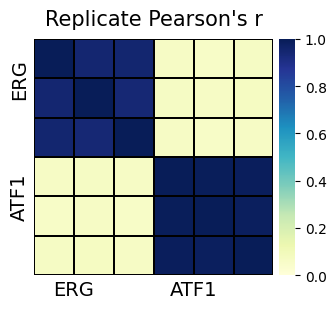

In [7]:
# Plot the replicate correlation heatmap.
plot_replicate_correlation_heatmap(sumprom_all_z, samples_to_plot)

## 7mer Binding Comparison

In [8]:
# Load the averaged 7mer signal files and combine them into one matrix.
kmer_7mer_files = glob.glob(kmer_7mer_files_glob)
dfs = [pd.read_csv(f, index_col="kmer") for f in kmer_7mer_files]
kmers = pd.concat(dfs, axis=1)

# Rename each column to the sample prefix and z-score the signal per sample.
kmers.columns = [get_prefix(f) for f in kmer_7mer_files]
kmers_z = kmers.apply(zscore)

In [9]:
# Plot ERG and ATF1 7mer scores while highlighting motif-like sequences.
def plot_two_columns_with_motifs_simple(
    df, col_x, col_y, motif1, motif2, window_size=7, point_size=10, randomize_zorder=True
):
    # Define the colors used for ERG-like, ATF1-like, and background 7mers.
    BLUE_BOLD = (0.25, 0.45, 0.95, 0.9)
    BLUE_FAINT = (0.25, 0.45, 0.95, 0.9)
    ORANGE_BOLD = (0.98, 0.45, 0.10, 0.9)
    ORANGE_FAINT = (0.98, 0.45, 0.10, 0.9)
    GREY = (0.72, 0.72, 0.72, 0.25)

    EDGE_BLUE = (0.1, 0.2, 0.6, 0.6)
    EDGE_ORANGE = (0.6, 0.25, 0.05, 0.6)
    EDGE_GREY = (0.65, 0.65, 0.65, 1)

    # Pull out the two signal columns and compare each 7mer to both motifs.
    x = df[col_x].values
    y = df[col_y].values
    m1 = motif1.upper()
    m2 = motif2.upper()

    xs, ys, colors, edges, widths = [], [], [], [], []

    for xi, yi, kmer in zip(x, y, df.index.astype(str)):
        s1 = iupac_similarity(kmer, m1)
        s2 = iupac_similarity(kmer, m2)
        best = max(s1, s2)

        # Color each point by the motif it matches best.
        if best < 6:
            colors.append(GREY)
            edges.append(EDGE_GREY)
            widths.append(0.25)
        elif s1 >= s2:
            colors.append(BLUE_BOLD if s1 == window_size else BLUE_FAINT)
            edges.append(EDGE_BLUE)
            widths.append(0.25)
        else:
            colors.append(ORANGE_BOLD if s2 == window_size else ORANGE_FAINT)
            edges.append(EDGE_ORANGE)
            widths.append(0.25)

        xs.append(xi)
        ys.append(yi)

    # Randomize point order so highlighted and background points mix naturally.
    if randomize_zorder:
        order = np.random.permutation(len(xs))
        xs = np.array(xs)[order]
        ys = np.array(ys)[order]
        colors = np.array(colors, dtype=object)[order]
        edges = np.array(edges, dtype=object)[order]
        widths = np.array(widths)[order]

    # Draw the scatterplot on matched x and y limits.
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.scatter(xs, ys, s=point_size, c=colors, edgecolors=edges, linewidths=widths, zorder=2)

    allv = np.concatenate([x, y])
    vmin, vmax = np.nanmin(allv), np.nanmax(allv)
    pad = 0.02 * (vmax - vmin if np.isfinite(vmax - vmin) else 1)
    ax.set_xlim(vmin - pad, vmax + pad)
    ax.set_ylim(vmin - pad, vmax + pad)
    ax.set_xlabel(f"{col_x} mean signal", fontsize=15)
    ax.set_ylabel(f"{col_y} mean signal", fontsize=15)
    ax.set_title("7mer binding", fontsize=16)

    # Add a legend that explains the motif classes.
    legend_elements = [
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor=BLUE_BOLD, markeredgecolor=EDGE_BLUE, markersize=6, label="ERG-like 7mer"),
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor=ORANGE_BOLD, markeredgecolor=EDGE_ORANGE, markersize=6, label="ATF1-like 7mer"),
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor=GREY, markeredgecolor=EDGE_GREY, markersize=6, label="Other 7mer"),
    ]
    ax.legend(handles=legend_elements, fontsize=12, handletextpad=-0.2)
    plt.tight_layout()
    plt.show()

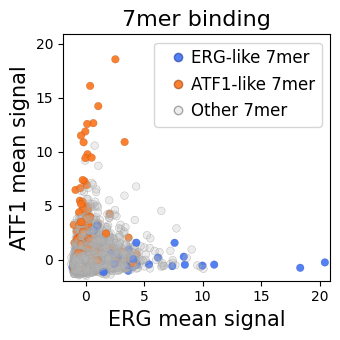

In [10]:
# Plot ERG and ATF1 7mer scores with motif-aware coloring.
plot_two_columns_with_motifs_simple(
    kmers_z, col_x="ERG", col_y="ATF1", motif1="CCGGAAR", motif2="RTGACGY", window_size=7, point_size=30
)

## Footprint Average Line Plots

In [11]:
# Load the ERG- and ATF1-centered footprint windows used for the two average-line plots.
erg_fp_on_erg = pd.read_csv(erg_fp_on_erg_path, index_col=0)
atf1_fp_on_erg = pd.read_csv(atf1_fp_on_erg_path, index_col=0)

erg_fp_on_atf1 = pd.read_csv(erg_fp_on_atf1_path, index_col=0)
atf1_fp_on_atf1 = pd.read_csv(atf1_fp_on_atf1_path, index_col=0)

In [12]:
# Plot the average footprint signal for two datasets and optionally add the motif logo below.
def plot_topN_average_line_two(
    df1,
    df2,
    *,
    top_n: int = 200,
    width: int = 100,
    dropna: bool = False,
    figsize: Tuple[float, float] = (3.5, 3.5),
    title: Optional[str] = None,
    linewidth: float = 1.5,
    window: Optional[int] = None,
    pfm_path: Optional[str] = None,
    legend_labels: Tuple[str, str] = ("df1", "df2"),
) -> plt.Figure:
    # Sort df1 by central signal and calculate the mean profile across the selected rows.
    df1_sorted, heat_cols1 = _sorted_and_window(df1, width)
    if dropna:
        df1_sorted = df1_sorted.dropna(subset=heat_cols1)
    n1 = min(top_n, len(df1_sorted))
    sub1 = df1_sorted.iloc[:n1][heat_cols1]
    y1 = sub1.mean(axis=0, skipna=True).to_numpy()
    xs1 = np.array([int(c.split("_", 1)[1]) for c in heat_cols1], dtype=int)
    if window is not None and window > 1:
        y1 = pd.Series(y1, index=xs1).rolling(window=window, center=True, min_periods=window).mean().to_numpy()

    # Sort df2 the same way and calculate the matching mean profile.
    df2_sorted, heat_cols2 = _sorted_and_window(df2, width)
    if dropna:
        df2_sorted = df2_sorted.dropna(subset=heat_cols2)
    n2 = min(top_n, len(df2_sorted))
    sub2 = df2_sorted.iloc[:n2][heat_cols2]
    y2 = sub2.mean(axis=0, skipna=True).to_numpy()
    xs2 = np.array([int(c.split("_", 1)[1]) for c in heat_cols2], dtype=int)
    if window is not None and window > 1:
        y2 = pd.Series(y2, index=xs2).rolling(window=window, center=True, min_periods=window).mean().to_numpy()

    # Draw a simple line plot if no motif logo was requested.
    if pfm_path is None:
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(xs1, y1, lw=linewidth, color=(0.25, 0.45, 0.95, 0.9), label=legend_labels[0])
        ax.plot(xs2, y2, lw=linewidth, color=(0.98, 0.45, 0.10, 0.9), label=legend_labels[1])
        ax.axvline(0, ls="--", alpha=0.2, color="black")
        ax.set_xlabel("Distance from motif (bp)", labelpad=1)
        ax.set_ylabel("Mean Signal")
        if title:
            ax.set_title(title)
        ax.legend(frameon=False)
        fig.tight_layout()
        return fig

    # Build a two-panel figure when a motif logo should be shown below the line plot.
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 1, height_ratios=[2, 0.5], hspace=0.4, figure=fig)

    # Plot the two average footprint profiles.
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(xs1, y1, lw=linewidth, color=(0.25, 0.45, 0.95, 0.9), label=legend_labels[0])
    ax1.plot(xs2, y2, lw=linewidth, color=(0.98, 0.45, 0.10, 0.9), label=legend_labels[1], zorder=0)
    ax1.axvline(0, ls="--", alpha=0.2, color="black")
    ax1.set_xlabel("Distance from motif (bp)", labelpad=0)
    ax1.set_ylabel("Mean Signal", fontsize=12, labelpad=-2)
    ax1.set_yticks([0, 20, 40])
    if title:
        ax1.set_title(title, fontsize=15)
    ax1.legend(frameon=False, fontsize=12, handlelength=1, handletextpad=0.2, loc="upper left")

    # Read the PFM, convert it to information content, and draw the logo.
    lines = []
    with open(pfm_path, "r") as fh:
        for ln in fh:
            ln = ln.strip()
            if ln:
                lines.append(ln)
    if lines and lines[0].startswith(">"):
        lines = lines[1:]

    vals = [list(map(float, ln.split())) for ln in lines]
    arr = np.asarray(vals, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 4:
        raise ValueError("PFM must have 4 columns per row (A C G T).")

    counts = pd.DataFrame(arr, columns=["A", "C", "G", "T"])
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    ic_mat = lm.transform_matrix(probs, from_type="probability", to_type="information")

    ax2 = fig.add_subplot(gs[1, 0])
    lm.Logo(ic_mat, ax=ax2)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlabel("")
    ax2.set_ylabel("")
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    # Shift the logo slightly so it sits neatly under the main plot.
    pos = ax2.get_position()
    ax2.set_position([pos.x0 + 0.12, pos.y0, pos.width * 0.7, pos.height])

    fig.tight_layout()
    return fig

/tmp/ipykernel_3571060/1763100326.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_3571060/1763100326.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


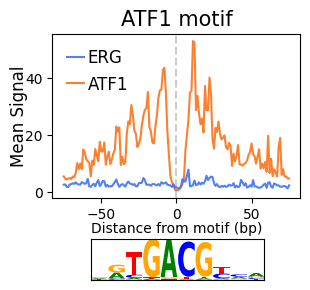

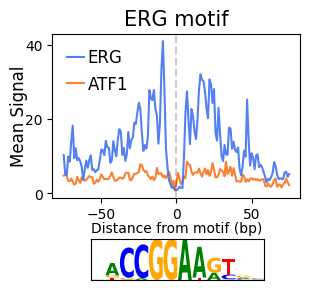

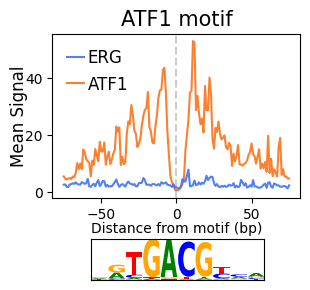

In [13]:
# Plot the average ERG- and ATF1-footprint profiles around ERG motif instances.
plot_topN_average_line_two(
    erg_fp_on_erg,
    atf1_fp_on_erg,
    legend_labels=["ERG", "ATF1"],
    title="ERG motif",
    dropna=False,
    width=75,
    top_n=200,
    window=0,
    pfm_path=erg_pfm,
    figsize=(3.2, 3.2),
)

# Plot the average ERG- and ATF1-footprint profiles around ATF1 motif instances.
plot_topN_average_line_two(
    erg_fp_on_atf1,
    atf1_fp_on_atf1,
    legend_labels=["ERG", "ATF1"],
    title="ATF1 motif",
    dropna=False,
    width=75,
    top_n=200,
    window=0,
    pfm_path=atf1_pfm,
    figsize=(3.2, 3.2),
)